# Lab 3: Manual Tool-Calling Swarm

**Swarm composition preview:** [teaching_diagrams/04_swarm_composition.svg](teaching_diagrams/04_swarm_composition.svg)

This lab keeps the Lab 2 question domain, but removes the supervisor and the prebuilt agent wrapper. The core swarm idea is still the same:

- the current specialist talks to the user directly,
- handoff tools transfer control to another specialist,
- `active_agent` persists across turns for the same `thread_id`.

This notebook starts Neo4j locally and seeds it from the committed typed structured profile dataset in Section 2, so the graph-backed swarm flow is fully reproducible from inside the notebook. We use two specialists:

- `ProfessorLookupAgent` handles named-professor questions.
- `ResearchMatchAgent` handles topic-to-professor questions.

Both specialists are explicit LangGraph subgraphs with a tiny `llm -> ToolNode -> llm` loop, so the tool-calling and handoff mechanics stay visible.

**Learn more:** [LangChain handoffs](https://docs.langchain.com/oss/python/langchain/multi-agent/handoffs), [LangGraph swarm reference](https://reference.langchain.com/python/langgraph-swarm/swarm/create_swarm), [LangGraph multi-agent concepts](https://raw.githubusercontent.com/langchain-ai/langgraph/main/docs/docs/concepts/multi_agent.md)


## 1. Environment Check

Learning goal: verify that this notebook is running inside the project environment and that the swarm package is available.

Theory: Lab 3 only works if three layers are in place before we talk about handoffs: a model, Neo4j access, and the swarm orchestration package. We keep the setup cell short so the rest of the notebook can stay focused on explicit swarm ownership and tool execution.


In [1]:
from __future__ import annotations

import json
import sys
import warnings
from importlib.metadata import version
from pathlib import Path
from typing import Any, Annotated

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
        if (candidate / "pyproject.toml").exists():
            PROJECT_ROOT = candidate
            break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore", message="IProgress not found.*")

from langchain.messages import AIMessage, SystemMessage, ToolMessage
from langchain_core.runnables import RunnableConfig
from langchain.tools import InjectedToolCallId, tool
from langgraph.config import get_stream_writer
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt import InjectedState, ToolNode
from langgraph.types import Command
from langgraph_swarm import SwarmState, create_swarm
from langgraph_swarm.handoff import METADATA_KEY_HANDOFF_DESTINATION

from bit_professor_chat.config import TutorSettings
from bit_professor_chat.model_factory import build_model
from bit_professor_chat.neo4j_queries import Neo4jQueryService

def pretty(data: Any) -> None:
    print(json.dumps(data, ensure_ascii=False, indent=2))

settings = TutorSettings.from_env(PROJECT_ROOT / ".env")
model = build_model(settings)
query_service = Neo4jQueryService(settings)

pretty(
    {
        "project_root": str(PROJECT_ROOT),
        "model": settings.lab_tutor_llm_model,
        "neo4j_uri": settings.neo4j_uri,
        "langgraph_swarm_version": version("langgraph-swarm"),
    }
)


{
  "project_root": "/Users/khajievroma/Projects/agents_tutorial",
  "model": "qwen3.5-plus",
  "neo4j_uri": "bolt://localhost:7687",
  "langgraph_swarm_version": "0.1.0"
}


## 2. Start Neo4j and Seed the Graph

Learning goal: start the local Neo4j service and load the committed Lab 3 professor graph directly from the notebook.

Theory: Lab 3 is built around a prepared typed professor graph. Instead of asking students to leave the notebook and seed Neo4j manually, we can do the setup here: bring up Docker for Neo4j, load the committed structured profile JSON files, and then verify the resulting counts before moving on to swarm handoffs.


In [2]:
import subprocess

from bit_professor_chat.graph_ingestion import insert_structured_output_to_neo4j

docker_result = subprocess.run(
    ["docker", "compose", "up", "-d", "neo4j"],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
)
if docker_result.returncode != 0:
    raise RuntimeError(
        "Could not start Neo4j with `docker compose up -d neo4j`.\n\n"
        f"stdout:\n{docker_result.stdout}\n\nstderr:\n{docker_result.stderr}"
    )

seed_summary = insert_structured_output_to_neo4j(
    settings=settings,
    project_root=PROJECT_ROOT,
    reset_database=True,
)

pretty(
    {
        "status": "seeded",
        "docker_command": "docker compose up -d neo4j",
        "seed_call": "insert_structured_output_to_neo4j(..., reset_database=True)",
        "professor_count": seed_summary.professor_count,
        "success_count": seed_summary.success_count,
        "node_count": seed_summary.node_count,
        "relationship_count": seed_summary.relationship_count,
    }
)


{
  "status": "seeded",
  "docker_command": "docker compose up -d neo4j",
  "seed_call": "insert_structured_output_to_neo4j(..., reset_database=True)",
  "professor_count": 44,
  "success_count": 44,
  "node_count": 1092,
  "relationship_count": 1247
}


## 3. Swarm Mental Model

Learning goal: make the control-flow difference between Lab 2 and Lab 3 explicit before we define any code.

Theory: Lab 2 used a supervisor. `StudentAgent` always stayed in charge, workers ran one task, and control returned to the supervisor. Lab 3 is different. The active agent owns the conversation directly. A handoff tool updates `active_agent`, and the next turn resumes from that remembered owner.


In [3]:
pretty(
    {
        "lab_2_supervisor": {
            "control": "StudentAgent stays in charge",
            "worker_return_path": "workers always return to the supervisor",
            "persistent_field": "route / worker_result / final_answer style query state",
        },
        "lab_3_swarm": {
            "control": "the current specialist owns the conversation",
            "worker_return_path": "no supervisor hop is required after a handoff",
            "persistent_field": "messages + active_agent only",
        },
    }
)


{
  "lab_2_supervisor": {
    "control": "StudentAgent stays in charge",
    "worker_return_path": "workers always return to the supervisor",
    "persistent_field": "route / worker_result / final_answer style query state"
  },
  "lab_3_swarm": {
    "control": "the current specialist owns the conversation",
    "worker_return_path": "no supervisor hop is required after a handoff",
    "persistent_field": "messages + active_agent only"
  }
}


## 4. Define the Deterministic Neo4j Tools

Learning goal: expose just enough tool surface for the two specialists.

Theory: both specialists talk to the same database, but they do not get the same tool set. This is the simplest useful example of tool partitioning inside a swarm.


In [4]:
def emit_teaching_event(event: dict[str, Any]) -> None:
    writer = get_stream_writer()
    writer(event)


@tool
def resolve_professor_tool(name_hint: str) -> dict[str, Any]:
    """Resolve a professor name hint into ranked Neo4j matches."""
    emit_teaching_event(
        {
            "kind": "tool_call",
            "agent": "ProfessorLookupAgent",
            "tool": "resolve_professor_tool",
            "input": {"name_hint": name_hint},
        }
    )
    matches, _ = query_service.resolve_professor(name_hint=name_hint, limit=5)
    result = {
        "matches": [match.to_dict() for match in matches],
    }
    emit_teaching_event(
        {
            "kind": "tool_result",
            "agent": "ProfessorLookupAgent",
            "tool": "resolve_professor_tool",
            "match_count": len(result["matches"]),
        }
    )
    return result


@tool
def get_professor_facts_tool(professor_name: str) -> dict[str, Any]:
    """Fetch a compact set of professor-grounded facts from Neo4j."""
    emit_teaching_event(
        {
            "kind": "tool_call",
            "agent": "ProfessorLookupAgent",
            "tool": "get_professor_facts_tool",
            "input": {"professor_name": professor_name},
        }
    )
    facts, _ = query_service.get_professor_facts(
        professor_name=professor_name,
        keywords=[],
        limit=10,
    )
    result = {
        "facts": [fact.to_dict() for fact in facts],
    }
    emit_teaching_event(
        {
            "kind": "tool_result",
            "agent": "ProfessorLookupAgent",
            "tool": "get_professor_facts_tool",
            "fact_count": len(result["facts"]),
        }
    )
    return result


@tool
def find_professors_by_topics_tool(keywords: list[str]) -> dict[str, Any]:
    """Recommend professors from a small list of topic keywords."""
    emit_teaching_event(
        {
            "kind": "tool_call",
            "agent": "ResearchMatchAgent",
            "tool": "find_professors_by_topics_tool",
            "input": {"keywords": keywords},
        }
    )
    matches, _ = query_service.find_professors_by_topics(
        keywords=keywords,
        limit=5,
    )
    result = {
        "matches": [match.to_dict() for match in matches],
    }
    emit_teaching_event(
        {
            "kind": "tool_result",
            "agent": "ResearchMatchAgent",
            "tool": "find_professors_by_topics_tool",
            "match_count": len(result["matches"]),
        }
    )
    return result


pretty(
    {
        "professor_lookup_tools": [
            resolve_professor_tool.name,
            get_professor_facts_tool.name,
        ],
        "research_match_tools": [find_professors_by_topics_tool.name],
    }
)


{
  "professor_lookup_tools": [
    "resolve_professor_tool",
    "get_professor_facts_tool"
  ],
  "research_match_tools": [
    "find_professors_by_topics_tool"
  ]
}


## 5. Build Custom Handoff Tools and Specialist Graphs

Learning goal: build two explicit specialist subgraphs with visible tool-calling and handoff logic.

Theory: each specialist is just a tiny LangGraph loop: an `llm` node decides what to do next, `ToolNode` executes Neo4j tools or a handoff tool, and the loop continues until the model stops requesting tools. The custom handoff tool is what updates `active_agent` in the parent swarm.


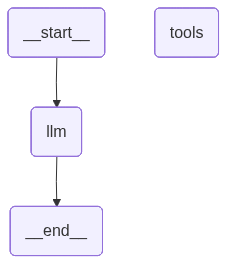

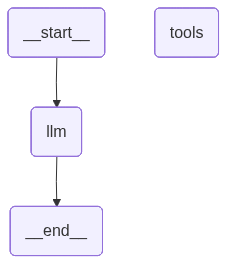

In [5]:
class Lab3State(SwarmState):
    """Lab 3 keeps only messages plus active_agent."""


def create_lab3_handoff_tool(
    *,
    agent_name: str,
    name: str,
    description: str,
):
    @tool(name, description=description)
    def handoff_to_agent(
        state: Annotated[Any, InjectedState],
        tool_call_id: Annotated[str, InjectedToolCallId],
    ) -> Command:
        emit_teaching_event(
            {
                "kind": "handoff",
                "from_agent": state.get("active_agent"),
                "to_agent": agent_name,
                "tool": name,
            }
        )
        tool_message = ToolMessage(
            content=f"Successfully transferred to {agent_name}",
            name=name,
            tool_call_id=tool_call_id,
        )
        return Command(
            goto=agent_name,
            graph=Command.PARENT,
            update={
                "messages": [*state["messages"], tool_message],
                "active_agent": agent_name,
            },
        )

    handoff_to_agent.metadata = {
        METADATA_KEY_HANDOFF_DESTINATION: agent_name
    }
    return handoff_to_agent


transfer_to_professor_lookup = create_lab3_handoff_tool(
    agent_name="ProfessorLookupAgent",
    name="transfer_to_professor_lookup",
    description="Hand off to ProfessorLookupAgent for named professor questions.",
)

transfer_to_research_match = create_lab3_handoff_tool(
    agent_name="ResearchMatchAgent",
    name="transfer_to_research_match",
    description="Hand off to ResearchMatchAgent for topic-to-professor matching.",
)


PROFESSOR_LOOKUP_PROMPT = """
You are ProfessorLookupAgent for the BIT professor graph.

Scope:
- Handle named-professor questions.
- Use Neo4j evidence returned by your tools.
- For named-professor questions, call resolve_professor_tool first.
- If you get one clear match, call get_professor_facts_tool before answering.

Handoff rule:
- If the user is asking for topic-based recommendations or "which professors should I look at", call transfer_to_research_match.

Answer style:
- Ground every answer in tool output.
- If the graph does not contain the answer, say so clearly.
- If name resolution is ambiguous, explain that ambiguity instead of guessing.
- Do not answer from prior knowledge.
""".strip()


RESEARCH_MATCH_PROMPT = """
You are ResearchMatchAgent for the BIT professor graph.

Scope:
- Recommend professors for a research direction or topic.
- Use find_professors_by_topics_tool with a short list of concrete keywords before answering.

Handoff rule:
- If the user is asking about one named professor, call transfer_to_professor_lookup.

Answer style:
- Ground every answer in tool output.
- Prefer concise recommendations with matched nodes when helpful.
- If the graph has no match, say that clearly instead of guessing.
- Do not answer from prior knowledge.
""".strip()


def build_specialist_agent(
    *,
    agent_name: str,
    system_prompt: str,
    tools: list[Any],
):
    bound_model = model.bind_tools(tools)
    tool_node = ToolNode(tools, name="tools")

    def call_model(state: Lab3State, config: RunnableConfig) -> dict[str, Any]:
        emit_teaching_event(
            {
                "kind": "agent_turn",
                "agent": agent_name,
                "message_count": len(state["messages"]),
                "thread_id": config["configurable"].get("thread_id"),
            }
        )
        response = bound_model.invoke(
            [SystemMessage(content=system_prompt), *state["messages"]]
        )
        return {
            "messages": [response],
            "active_agent": agent_name,
        }

    def route_after_model(state: Lab3State):
        last_message = state["messages"][-1]
        if isinstance(last_message, AIMessage) and last_message.tool_calls:
            return "tools"
        return END

    workflow = StateGraph(Lab3State)
    workflow.add_node("llm", call_model)
    workflow.add_node("tools", tool_node)
    workflow.add_edge(START, "llm")
    workflow.add_conditional_edges("llm", route_after_model)
    workflow.add_edge("tools", "llm")
    return workflow.compile(name=agent_name)


professor_lookup_agent = build_specialist_agent(
    agent_name="ProfessorLookupAgent",
    system_prompt=PROFESSOR_LOOKUP_PROMPT,
    tools=[
        resolve_professor_tool,
        get_professor_facts_tool,
        transfer_to_research_match,
    ],
)

research_match_agent = build_specialist_agent(
    agent_name="ResearchMatchAgent",
    system_prompt=RESEARCH_MATCH_PROMPT,
    tools=[
        find_professors_by_topics_tool,
        transfer_to_professor_lookup,
    ],
)
from IPython.display import HTML, Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(HTML("<strong>ProfessorLookupAgent graph</strong>"))
display(
    Image(
        professor_lookup_agent.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

display(HTML("<strong>ResearchMatchAgent graph</strong>"))
display(
    Image(
        research_match_agent.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)


## 6. Compile the Swarm with Memory

Learning goal: compile the swarm with `InMemorySaver` and keep the state as small as possible.

Theory: `create_swarm(...)` is still the parent orchestration layer. The only persistent Lab 3 state is `messages` plus `active_agent`, and the specialists themselves are now explicit compiled subgraphs rather than prebuilt agents.


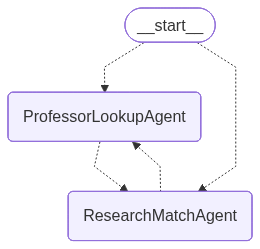

In [6]:
swarm_workflow = create_swarm(
    [
        professor_lookup_agent,
        research_match_agent,
    ],
    default_active_agent="ProfessorLookupAgent",
    state_schema=Lab3State,
)
swarm_app = swarm_workflow.compile(checkpointer=InMemorySaver())

display(HTML("<strong>Whole swarm graph</strong>"))
display(
    Image(
        swarm_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)


## 7. Gradio App

Learning goal: interact with the swarm through a small UI and inspect handoffs, tool usage, `active_agent`, and same-thread memory without exposing chain-of-thought.

Theory: the chat stays student-friendly on the left, while the right panel surfaces only the swarm mechanics we care about: which specialist acted, which deterministic Neo4j tool ran, when a handoff happened, and which `thread_id` is still carrying memory. Resetting the app creates a fresh `thread_id`, so students can see the same memory rule from Step 9 in a more interactive form first.


In [7]:
import time
import uuid

import gradio as gr

VISIBLE_REPLY_PLACEHOLDER = "_Swarm is thinking..._"

GRADIO_EXAMPLES = [
    "What are CHENG Cheng's research interests?",
    "Show me a few facts about CHE Haiying.",
    "I am interested in computer vision and multimedia content analysis. Which professors should I look at?",
]


def content_to_text(content: Any) -> str:
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        parts: list[str] = []
        for item in content:
            if isinstance(item, str):
                parts.append(item)
            elif isinstance(item, dict):
                text = item.get("text") or item.get("content")
                parts.append(str(text) if text else json.dumps(item, ensure_ascii=False))
            else:
                parts.append(str(item))
        return "".join(parts)
    return str(content)


def json_safe(value: Any) -> Any:
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [json_safe(item) for item in value]
    if hasattr(value, "model_dump"):
        try:
            return json_safe(value.model_dump())
        except Exception:
            pass
    return str(value)


def shorten_text(text: str, limit: int = 1200) -> str:
    normalized = text.strip()
    if not normalized:
        return "(empty)"
    if len(normalized) <= limit:
        return normalized
    return normalized[:limit].rstrip() + "\n... (truncated)"


def format_block(value: Any) -> str:
    if isinstance(value, str):
        stripped = value.strip()
        if not stripped:
            return "_Waiting for more streamed content..._"
        try:
            parsed = json.loads(stripped)
        except Exception:
            rendered = shorten_text(stripped)
            return f"```text\n{rendered}\n```"
        return f"```json\n{json.dumps(parsed, ensure_ascii=False, indent=2)}\n```"
    return f"```json\n{json.dumps(json_safe(value), ensure_ascii=False, indent=2)}\n```"


def build_thread_id() -> str:
    return f"lab3-gradio-{uuid.uuid4().hex[:8]}"


def next_trace_id(session: dict[str, Any], prefix: str) -> str:
    session["trace_counter"] += 1
    return f"{prefix}-{session['trace_counter']}"


def new_gradio_session() -> dict[str, Any]:
    return {
        "thread_id": build_thread_id(),
        "chat_messages": [],
        "trace_counter": 0,
        "pending_tool_trace_ids": {},
        "current_run": None,
    }


def find_message_index(chat_messages: list[dict[str, Any]], message_id: str | None) -> int:
    if not message_id:
        return -1
    for index, message in enumerate(chat_messages):
        metadata = dict(message.get("metadata") or {})
        if metadata.get("id") == message_id:
            return index
    return -1


def find_visible_reply_index(chat_messages: list[dict[str, Any]], reply_id: str | None) -> int:
    reply_index = find_message_index(chat_messages, reply_id)
    if reply_index == -1:
        return -1
    metadata = dict(chat_messages[reply_index].get("metadata") or {})
    if chat_messages[reply_index].get("role") != "assistant":
        return -1
    if metadata.get("title"):
        return -1
    return reply_index


def upsert_trace_message(
    chat_messages: list[dict[str, Any]],
    *,
    trace_id: str,
    title: str,
    content: str,
    parent_id: str | None = None,
    status: str | None = None,
    log: str | None = None,
    before_id: str | None = None,
) -> list[dict[str, Any]]:
    updated_messages = list(chat_messages)
    metadata: dict[str, Any] = {"title": title, "id": trace_id}
    if parent_id is not None:
        metadata["parent_id"] = parent_id
    if status is not None:
        metadata["status"] = status
    if log:
        metadata["log"] = log

    message = {
        "role": "assistant",
        "content": content,
        "metadata": metadata,
    }
    message_index = find_message_index(updated_messages, trace_id)
    if message_index == -1:
        insert_index = find_message_index(updated_messages, before_id)
        if insert_index == -1:
            updated_messages.append(message)
        else:
            updated_messages.insert(insert_index, message)
    else:
        updated_messages[message_index] = message
    return updated_messages


def ensure_visible_reply(
    chat_messages: list[dict[str, Any]],
    *,
    reply_id: str,
    content: str = VISIBLE_REPLY_PLACEHOLDER,
) -> list[dict[str, Any]]:
    updated_messages = list(chat_messages)
    reply_index = find_visible_reply_index(updated_messages, reply_id)
    if reply_index == -1:
        updated_messages.append(
            {
                "role": "assistant",
                "content": content,
                "metadata": {"id": reply_id},
            }
        )
        return updated_messages
    if not str(updated_messages[reply_index].get("content", "")).strip():
        updated_messages[reply_index] = {
            **updated_messages[reply_index],
            "content": content,
        }
    return updated_messages


def append_assistant_text(
    chat_messages: list[dict[str, Any]],
    text: str,
    *,
    reply_id: str,
) -> list[dict[str, Any]]:
    updated_messages = ensure_visible_reply(chat_messages, reply_id=reply_id)
    reply_index = find_visible_reply_index(updated_messages, reply_id)
    reply_message = updated_messages[reply_index]
    current_content = str(reply_message.get("content", ""))
    next_content = text if current_content == VISIBLE_REPLY_PLACEHOLDER else current_content + text
    updated_messages[reply_index] = {
        **reply_message,
        "content": next_content,
    }
    return updated_messages


def replace_assistant_text(
    chat_messages: list[dict[str, Any]],
    text: str,
    *,
    reply_id: str,
) -> list[dict[str, Any]]:
    updated_messages = ensure_visible_reply(chat_messages, reply_id=reply_id)
    reply_index = find_visible_reply_index(updated_messages, reply_id)
    updated_messages[reply_index] = {
        **updated_messages[reply_index],
        "content": text,
    }
    return updated_messages


def agent_name_from_metadata(metadata: dict[str, Any] | None) -> str | None:
    if not isinstance(metadata, dict):
        return None
    if metadata.get("lc_agent_name"):
        return str(metadata["lc_agent_name"])
    checkpoint_ns = metadata.get("checkpoint_ns") or metadata.get("langgraph_checkpoint_ns")
    if checkpoint_ns:
        namespace = str(checkpoint_ns).split("|", 1)[0]
        return namespace.split(":", 1)[0]
    return None


def build_run_trace_content(session: dict[str, Any]) -> str:
    run = dict(session.get("current_run") or {})
    elapsed = time.time() - float(run.get("started_at", time.time()))
    lines = [
        "The assistant reply is the normal message bubble below.",
        "Expand the cards to inspect handoffs and Neo4j tool usage.",
        "",
        f"Thread id: `{session.get('thread_id')}`",
        f"Current specialist: `{run.get('last_agent_name') or 'ProfessorLookupAgent'}`",
        f"Run state: `{run.get('run_state', 'idle')}`",
    ]
    if run.get("latest_action"):
        lines.append(f"Latest action: `{run['latest_action']}`")
    if run.get("run_state") in {"complete", "failed"}:
        lines.append(f"Elapsed: `{elapsed:.1f}s`")
        if run.get("stored_message_count") is not None:
            lines.append(f"Stored LangGraph messages: `{run['stored_message_count']}`")
    return "\n".join(lines)


def sync_run_trace(
    chat_messages: list[dict[str, Any]],
    session: dict[str, Any],
    *,
    swarm_state: dict[str, Any] | None = None,
) -> list[dict[str, Any]]:
    run = dict(session.get("current_run") or {})
    if not run:
        return chat_messages
    if swarm_state is not None:
        run["stored_message_count"] = swarm_state.get("stored_message_count")
        if swarm_state.get("active_agent"):
            run["last_agent_name"] = swarm_state["active_agent"]
        session["current_run"] = run
    return upsert_trace_message(
        chat_messages,
        trace_id=run["root_id"],
        title="SWARM LOOP",
        content=build_run_trace_content(session),
        status="done" if run.get("run_state") in {"complete", "failed"} else "pending",
        log=run.get("latest_action") or run.get("last_agent_name") or "ProfessorLookupAgent",
        before_id=run.get("reply_id"),
    )


def format_tool_call_content(event: dict[str, Any]) -> str:
    parts = [
        f"Agent: `{event.get('agent') or 'unknown'}`",
        f"Tool: `{event.get('tool') or 'unknown'}`",
    ]
    if event.get("input") is not None:
        parts.extend(["Input:", format_block(event["input"])])
    return "\n\n".join(parts)


def format_tool_result_content(event: dict[str, Any]) -> str:
    summary = {
        key: value
        for key, value in event.items()
        if key not in {"kind", "agent", "tool"}
    }
    parts = [
        f"Agent: `{event.get('agent') or 'unknown'}`",
        f"Tool: `{event.get('tool') or 'unknown'}`",
        "Summary:",
        format_block(summary or {"message": "Tool finished without a summary payload."}),
    ]
    return "\n\n".join(parts)


def format_handoff_content(event: dict[str, Any]) -> str:
    payload = {
        "from_agent": event.get("from_agent"),
        "to_agent": event.get("to_agent"),
        "tool": event.get("tool"),
    }
    return format_block(payload)


def pending_tool_key(event: dict[str, Any]) -> str:
    return f"{event.get('agent') or 'unknown'}::{event.get('tool') or 'unknown'}"


def record_tool_call(
    chat_messages: list[dict[str, Any]],
    session: dict[str, Any],
    event: dict[str, Any],
) -> list[dict[str, Any]]:
    run = dict(session.get("current_run") or {})
    run["last_agent_name"] = event.get("agent") or run.get("last_agent_name")
    run["latest_action"] = f"{event.get('agent') or 'Agent'} called {event.get('tool') or 'a tool'}"
    session["current_run"] = run

    trace_id = next_trace_id(session, "tool-call")
    pending = dict(session.get("pending_tool_trace_ids") or {})
    queue = list(pending.get(pending_tool_key(event), []))
    queue.append(trace_id)
    pending[pending_tool_key(event)] = queue
    session["pending_tool_trace_ids"] = pending

    return upsert_trace_message(
        chat_messages,
        trace_id=trace_id,
        title=f"TOOL CALL · {event.get('tool') or 'tool'}",
        content=format_tool_call_content(event),
        parent_id=run["root_id"],
        status="pending",
        before_id=run.get("reply_id"),
    )


def record_tool_result(
    chat_messages: list[dict[str, Any]],
    session: dict[str, Any],
    event: dict[str, Any],
) -> list[dict[str, Any]]:
    run = dict(session.get("current_run") or {})
    run["last_agent_name"] = event.get("agent") or run.get("last_agent_name")
    run["latest_action"] = f"{event.get('agent') or 'Agent'} received {event.get('tool') or 'tool'} results"
    session["current_run"] = run

    pending = dict(session.get("pending_tool_trace_ids") or {})
    queue = list(pending.get(pending_tool_key(event), []))
    parent_id = queue.pop(0) if queue else run["root_id"]
    if queue:
        pending[pending_tool_key(event)] = queue
    else:
        pending.pop(pending_tool_key(event), None)
    session["pending_tool_trace_ids"] = pending

    return upsert_trace_message(
        chat_messages,
        trace_id=next_trace_id(session, "tool-result"),
        title=f"TOOL RESULT · {event.get('tool') or 'tool'}",
        content=format_tool_result_content(event),
        parent_id=parent_id,
        status="done",
        before_id=run.get("reply_id"),
    )


def record_handoff(
    chat_messages: list[dict[str, Any]],
    session: dict[str, Any],
    event: dict[str, Any],
) -> list[dict[str, Any]]:
    run = dict(session.get("current_run") or {})
    run["last_agent_name"] = event.get("to_agent") or run.get("last_agent_name")
    run["latest_action"] = (
        f"{event.get('from_agent') or 'Agent'} handed off to {event.get('to_agent') or 'another specialist'}"
    )
    session["current_run"] = run
    return upsert_trace_message(
        chat_messages,
        trace_id=next_trace_id(session, "handoff"),
        title="HANDOFF",
        content=format_handoff_content(event),
        parent_id=run["root_id"],
        status="done",
        before_id=run.get("reply_id"),
    )


def record_custom_event(
    chat_messages: list[dict[str, Any]],
    session: dict[str, Any],
    raw_event: dict[str, Any],
) -> list[dict[str, Any]]:
    event = dict(raw_event)
    kind = event.get("kind")

    if kind == "agent_turn":
        run = dict(session.get("current_run") or {})
        run["last_agent_name"] = event.get("agent") or run.get("last_agent_name")
        run["latest_action"] = f"{event.get('agent') or 'Agent'} is thinking"
        session["current_run"] = run
        return chat_messages
    if kind == "tool_call":
        return record_tool_call(chat_messages, session, event)
    if kind == "tool_result":
        return record_tool_result(chat_messages, session, event)
    if kind == "handoff":
        return record_handoff(chat_messages, session, event)

    run = dict(session.get("current_run") or {})
    run["latest_action"] = f"custom event: {kind or 'unknown'}"
    session["current_run"] = run
    return upsert_trace_message(
        chat_messages,
        trace_id=next_trace_id(session, "event"),
        title=f"EVENT · {kind or 'unknown'}",
        content=format_block(event),
        parent_id=run["root_id"],
        status="done",
        before_id=run.get("reply_id"),
    )


def read_swarm_state(thread_id: str) -> dict[str, Any]:
    config = {"configurable": {"thread_id": thread_id}}
    try:
        state_values = dict(swarm_app.get_state(config).values)
    except Exception as exc:
        return {
            "thread_id": thread_id,
            "error": str(exc),
            "stored_message_count": None,
            "active_agent": None,
            "final_reply": "",
        }

    stored_messages = list(state_values.get("messages", []))
    final_reply = ""
    for message in reversed(stored_messages):
        if isinstance(message, ToolMessage):
            continue
        tool_calls = getattr(message, "tool_calls", None) or []
        content = content_to_text(getattr(message, "content", ""))
        if content.strip() and not tool_calls:
            final_reply = content.strip()
            break

    return {
        "thread_id": thread_id,
        "stored_message_count": len(stored_messages),
        "active_agent": state_values.get("active_agent"),
        "final_reply": final_reply,
    }


def publish_session(session: dict[str, Any], chat_messages: list[dict[str, Any]]):
    session["chat_messages"] = chat_messages
    return "", chat_messages, session


def ask_swarm(prompt: str, session_state: dict[str, Any] | None):
    session = dict(session_state or new_gradio_session())
    prompt = prompt.strip()
    if not prompt:
        yield publish_session(session, session["chat_messages"])
        return

    thread_id = session["thread_id"]
    config = {"configurable": {"thread_id": thread_id}}
    session["pending_tool_trace_ids"] = {}
    root_id = next_trace_id(session, "run")
    reply_id = next_trace_id(session, "reply")
    session["current_run"] = {
        "root_id": root_id,
        "reply_id": reply_id,
        "started_at": time.time(),
        "run_state": "streaming",
        "last_agent_name": "ProfessorLookupAgent",
        "latest_action": "waiting for the first tool or reply token",
        "stored_message_count": None,
    }

    chat_messages = [*session["chat_messages"], {"role": "user", "content": prompt}]
    chat_messages = ensure_visible_reply(chat_messages, reply_id=reply_id)
    chat_messages = sync_run_trace(chat_messages, session)
    yield publish_session(session, chat_messages)

    try:
        for part in swarm_app.stream(
            {"messages": [{"role": "user", "content": prompt}]},
            config=config,
            stream_mode=["messages", "custom"],
            subgraphs=True,
            version="v2",
        ):
            if part["type"] == "messages":
                token, metadata = part["data"]
                agent_name = agent_name_from_metadata(metadata)
                node_name = metadata.get("langgraph_node") if isinstance(metadata, dict) else None
                token_text = content_to_text(getattr(token, "content", ""))
                if agent_name:
                    run = dict(session.get("current_run") or {})
                    run["last_agent_name"] = agent_name
                    session["current_run"] = run
                if node_name == "llm" and token_text:
                    run = dict(session.get("current_run") or {})
                    run["latest_action"] = f"{run.get('last_agent_name') or agent_name or 'Agent'} is writing the answer"
                    session["current_run"] = run
                    chat_messages = append_assistant_text(
                        chat_messages,
                        token_text,
                        reply_id=run["reply_id"],
                    )
            elif part["type"] == "custom":
                chat_messages = record_custom_event(chat_messages, session, part.get("data") or {})

            chat_messages = sync_run_trace(chat_messages, session)
            yield publish_session(session, chat_messages)

        swarm_state = read_swarm_state(thread_id)
        final_reply = swarm_state.get("final_reply", "")
        if final_reply:
            chat_messages = replace_assistant_text(
                chat_messages,
                final_reply,
                reply_id=session["current_run"]["reply_id"],
            )

        run = dict(session.get("current_run") or {})
        run["run_state"] = "complete"
        session["current_run"] = run
        chat_messages = sync_run_trace(chat_messages, session, swarm_state=swarm_state)
        yield publish_session(session, chat_messages)
    except Exception as exc:
        error_message = f"Swarm query failed: {exc}"
        run = dict(session.get("current_run") or {})
        run["run_state"] = "failed"
        run["latest_action"] = error_message
        session["current_run"] = run
        chat_messages = replace_assistant_text(
            chat_messages,
            error_message,
            reply_id=run["reply_id"],
        )
        chat_messages = sync_run_trace(
            chat_messages,
            session,
            swarm_state={
                "thread_id": thread_id,
                "stored_message_count": None,
                "active_agent": run.get("last_agent_name"),
                "final_reply": "",
            },
        )
        yield publish_session(session, chat_messages)


def reset_swarm_chat():
    session = new_gradio_session()
    return publish_session(session, session["chat_messages"])


initial_session = new_gradio_session()

with gr.Blocks(fill_width=True) as demo:
    gr.Markdown(
        """### Lab 3 Gradio App
Ask the notebook-local swarm a question. The main assistant reply streams in the normal chat bubble, and the swarm mechanics appear as expandable in-chat cards for handoffs and Neo4j tool activity."""
    )

    session_state = gr.State(initial_session)
    chatbot = gr.Chatbot(
        label="Swarm conversation",
        height=720,
        value=initial_session["chat_messages"],
        group_consecutive_messages=False,
    )
    prompt = gr.Textbox(
        label="Ask the Lab 3 swarm",
        placeholder="Try one of the example prompts below.",
    )
    with gr.Row():
        ask_button = gr.Button("Ask", variant="primary")
        reset_button = gr.Button("Start a new chat")
    gr.Examples(examples=GRADIO_EXAMPLES, inputs=prompt)

    ask_button.click(
        ask_swarm,
        inputs=[prompt, session_state],
        outputs=[prompt, chatbot, session_state],
    )
    prompt.submit(
        ask_swarm,
        inputs=[prompt, session_state],
        outputs=[prompt, chatbot, session_state],
    )
    reset_button.click(
        reset_swarm_chat,
        outputs=[prompt, chatbot, session_state],
    )

demo.launch(inline=False, inbrowser=True, height=980, width="100%", prevent_thread_lock=True)



* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
